In [10]:
# Reprodukcija grafika iz Prywes et al. 2025
# Analiza fitness landscape-a rubisco enzima koristeci dataset iz Prywes N. et al., "A map of the rubisco biochemical landscape" Nature 2025

In [2]:

import pandas as pd

df = pd.read_csv(r"C:\Users\ilija\rubiscodms\41586_2024_8455_MOESM4_ESM.csv")

print(df.shape)        # koliko redova i kolona
print(df.columns.tolist())  # nazivi kolona
print(df.head(10))     # prvih 10 redova

(8760, 19)
['Unnamed: 0', 'mutant', 'position', 'WTresidue', 'residue', 'rep1', 'rep2', 'rep3', 'rep4', 'rep5', 'rep6', 'rep7', 'rep8', 'rep9', 'Fitness', 'Km_median', 'Km_qbcov', 'Vmax_median', 'Vmax_qbcov']
   Unnamed: 0 mutant  position WTresidue residue      rep1      rep2  \
0        6397    Q3Y         3         Q       Y  0.395171  0.348857   
1        6380    Q3C         3         Q       C  0.750400  0.744063   
2        6381    Q3D         3         Q       D  0.354563  0.428215   
3        6382    Q3E         3         Q       E  0.361705  0.427675   
4        6383    Q3F         3         Q       F  0.654394  0.658501   
5        6384    Q3G         3         Q       G  0.047590  0.014039   
6        6385    Q3H         3         Q       H  0.848579  0.924667   
7        6386    Q3I         3         Q       I  0.784703  0.707211   
8        6387    Q3K         3         Q       K  0.812161  0.764572   
9        6379    Q3A         3         Q       A  0.570451  0.614970   

In [3]:
# osnovne statistike
print(f"Ukupno mutanata: {len(df)}")
print(f"Dead mutanti (Fitness < 0.1): {len(df[df['Fitness'] < 0.1])}")
print(f"Neutralni (Fitness > 0.8): {len(df[df['Fitness'] > 0.8])}")
print(f"Bolji od WT (Fitness > 1.0): {len(df[df['Fitness'] > 1.0])}")

print()

# pronađi A102Y i V266T
a102y = df[df['mutant'] == 'A102Y']
v266t = df[df['mutant'] == 'V266T']

print(f"A102Y — Fitness: {a102y['Fitness'].values[0]:.3f}, KC: {a102y['Km_median'].values[0]:.1f} μM")
print(f"V266T — Fitness: {v266t['Fitness'].values[0]:.3f}, KC: {v266t['Km_median'].values[0]:.1f} μM")

Ukupno mutanata: 8760
Dead mutanti (Fitness < 0.1): 2305
Neutralni (Fitness > 0.8): 3727
Bolji od WT (Fitness > 1.0): 464

A102Y — Fitness: 0.629, KC: 0.1 μM
V266T — Fitness: 0.892, KC: 0.1 μM


In [4]:
# pogledaj KC vrednosti za poznate mutante
print(df[df['mutant'].isin(['A102Y', 'V266T', 'Q3Y'])][['mutant', 'Fitness', 'Km_median']].head(10))

# i generalni opseg KC vrednosti
print(f"\nKm_median min: {df['Km_median'].min():.4f}")
print(f"Km_median max: {df['Km_median'].max():.4f}")
print(f"Km_median mean: {df['Km_median'].mean():.4f}")

# koliko mutanata ima KC vrednost (nije NaN)
print(f"\nMutanti sa KC vrednosti: {df['Km_median'].notna().sum()}")

     mutant   Fitness  Km_median
0       Q3Y  0.397403   1.670726
1879  A102Y  0.629357   0.121362
4994  V266T  0.891749   0.132980

Km_median min: 0.0346
Km_median max: 4.2790
Km_median mean: 0.3069

Mutanti sa KC vrednosti: 8760


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# konvertuj u μM
df['KC_uM'] = df['Km_median'] * 150

# scatter plot KC vs Fitness — kao Fig. 4a iz rada
plt.figure(figsize=(8, 5))

# svi mutanti
plt.scatter(df['Fitness'], df['KC_uM'], 
            alpha=0.1, s=3, color='gray', label='svi mutanti')

# istakni A102Y i V266T
for mutant, color in [('A102Y', 'teal'), ('V266T', 'coral')]:
    m = df[df['mutant'] == mutant]
    plt.scatter(m['Fitness'], m['KC_uM'], 
                color=color, s=80, zorder=5, label=mutant)
    plt.annotate(mutant, 
                 (m['Fitness'].values[0], m['KC_uM'].values[0]),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)

# WT linija
plt.axhline(y=150, color='black', linestyle='--', alpha=0.5, label='WT KC')
plt.axvline(x=1.0, color='black', linestyle=':', alpha=0.5, label='WT fitness')

plt.xlabel("fitness")
plt.ylabel("KC (μM)")
plt.title("Fitness vs KC — pravi Prywes d

SyntaxError: unterminated string literal (detected at line 29) (2686851636.py, line 29)

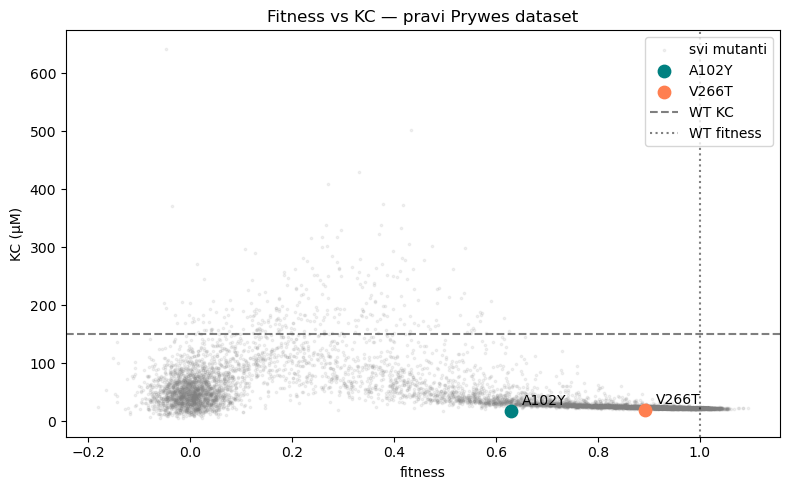

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# konvertuj u μM
df['KC_uM'] = df['Km_median'] * 150

# scatter plot KC vs Fitness — kao Fig. 4a iz rada
plt.figure(figsize=(8, 5))

# svi mutanti
plt.scatter(df['Fitness'], df['KC_uM'], 
            alpha=0.1, s=3, color='gray', label='svi mutanti')

# istakni A102Y i V266T
for mutant, color in [('A102Y', 'teal'), ('V266T', 'coral')]:
    m = df[df['mutant'] == mutant]
    plt.scatter(m['Fitness'], m['KC_uM'], 
                color=color, s=80, zorder=5, label=mutant)
    plt.annotate(mutant, 
                 (m['Fitness'].values[0], m['KC_uM'].values[0]),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)

# WT linija
plt.axhline(y=150, color='black', linestyle='--', alpha=0.5, label='WT KC')
plt.axvline(x=1.0, color='black', linestyle=':', alpha=0.5, label='WT fitness')

plt.xlabel("fitness")
plt.ylabel("KC (μM)")
plt.title("Fitness vs KC — pravi Prywes dataset")
plt.legend()
plt.tight_layout()
plt.savefig("fitness_vs_kc.png", dpi=150)
plt.show()

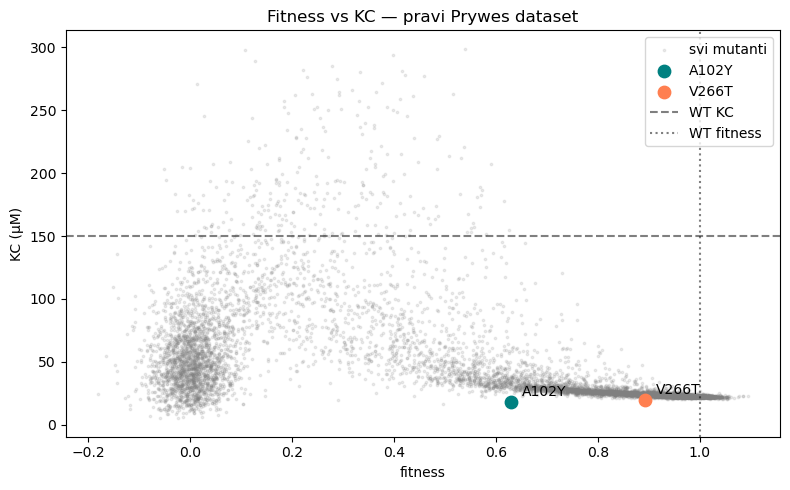

In [7]:
plt.figure(figsize=(8, 5))

# filtriraj samo mutante sa KC < 300 za bolji prikaz
df_plot = df[df['KC_uM'] < 300]

plt.scatter(df_plot['Fitness'], df_plot['KC_uM'],
            alpha=0.15, s=3, color='gray', label='svi mutanti')

for mutant, color in [('A102Y', 'teal'), ('V266T', 'coral')]:
    m = df[df['mutant'] == mutant]
    plt.scatter(m['Fitness'], m['KC_uM'],
                color=color, s=80, zorder=5, label=mutant)
    plt.annotate(mutant,
                 (m['Fitness'].values[0], m['KC_uM'].values[0]),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)

plt.axhline(y=150, color='black', linestyle='--', alpha=0.5, label='WT KC')
plt.axvline(x=1.0, color='black', linestyle=':', alpha=0.5, label='WT fitness')

plt.xlabel("fitness")
plt.ylabel("KC (μM)")
plt.title("Fitness vs KC — pravi Prywes dataset")
plt.legend()
plt.tight_layout()
plt.savefig("fitness_vs_kc_zoom.png", dpi=150)
plt.show()

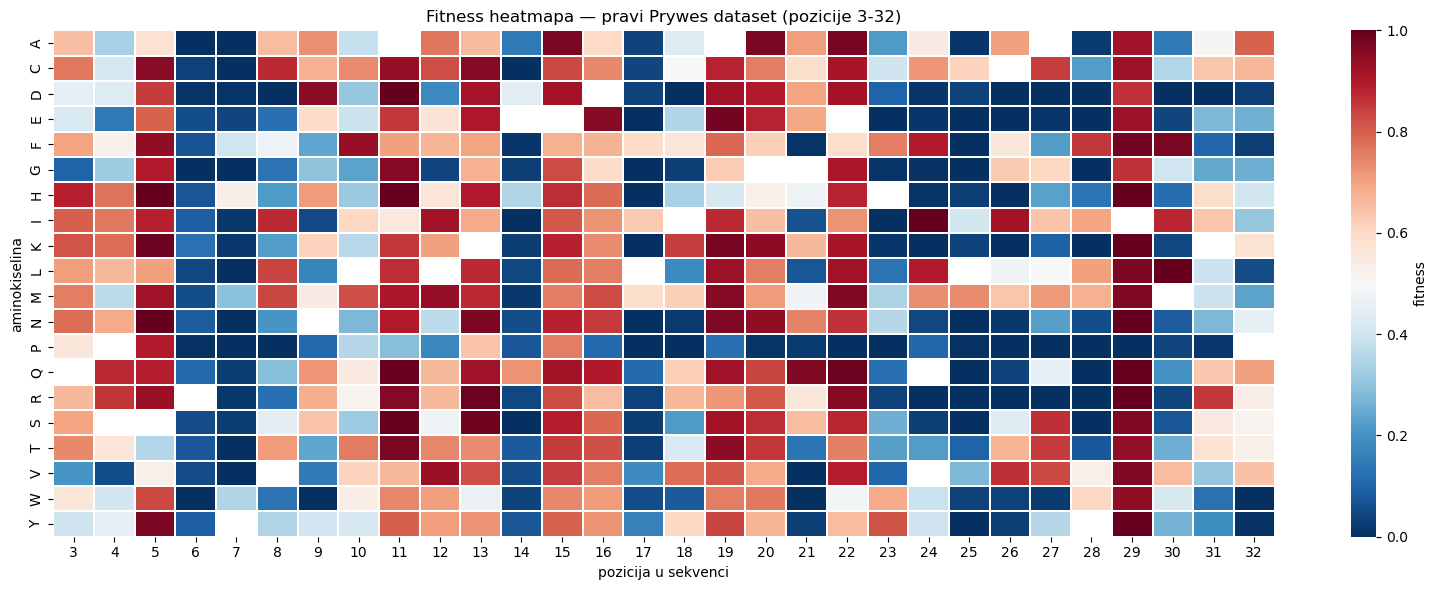

In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# pivot tabela: aminokiseline kao redovi, pozicije kao kolone
pivot = df.pivot_table(
    index='residue', 
    columns='position', 
    values='Fitness'
)

# samo prvih 30 pozicija da bude čitljivo
pivot_small = pivot.iloc[:, :30]

plt.figure(figsize=(16, 6))

sns.heatmap(
    pivot_small,
    cmap='RdBu_r',
    vmin=0, vmax=1,
    linewidths=0.1,
    linecolor='white',
    cbar_kws={'label': 'fitness'}
)

plt.title("Fitness heatmapa — pravi Prywes dataset (pozicije 3-32)")
plt.xlabel("pozicija u sekvenci")
plt.ylabel("aminokiselina")
plt.tight_layout()
plt.savefig("heatmapa_prava.png", dpi=150)
plt.show()